# Phase 5 - Evaluation & Interpretability


### Step 1 - Setting up the required data
##### First, we will import our necessary libraries and load the preprocessed datasets generated in Phase 2.

In [28]:
# Phase 5: Evaluation & Interpretability
# Part 1: Import Libraries
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score, roc_auc_score,
    balanced_accuracy_score, matthews_corrcoef, precision_recall_curve
)

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [29]:
# connectign drive to copy X_train_final.csv
from google.colab import drive
drive.mount('/content/drive')

!cp "/content/drive/MyDrive/X_train_final.csv" /content/

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [30]:
X_train = pd.read_csv("X_train_final.csv")
y_train = pd.read_csv("y_train_final.csv").squeeze()
X_val = pd.read_csv("X_val_final.csv")
y_val = pd.read_csv("y_val_final.csv").squeeze()

# Load held-out test data
X_test = pd.read_csv("X_test_final.csv")
y_test = pd.read_csv("y_test_final.csv").squeeze()

# Clean feature names for XGBoost compatibility
X_train = X_train.rename(columns=lambda c: str(c).replace("[", "_").replace("]", "_").replace("<", "_"))
X_val   = X_val.rename(columns=lambda c: str(c).replace("[", "_").replace("]", "_").replace("<", "_"))
X_test  = X_test.rename(columns=lambda c: str(c).replace("[", "_").replace("]", "_").replace("<", "_"))

print("Training and validation data loaded successfully!")
print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")

print("\nHeld-out test data loaded successfully!")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

Training and validation data loaded successfully!
X_train shape: (91314, 2136)
X_val shape: (10728, 2136)

Held-out test data loaded successfully!
X_test shape: (10728, 2136)
y_test shape: (10728,)


In [31]:
# Cleaning feature names for XGBoost compatibility
X_train = X_train.rename(columns=lambda c: str(c).replace("[", "_").replace("]", "_").replace("<", "_"))
X_val   = X_val.rename(columns=lambda c: str(c).replace("[", "_").replace("]", "_").replace("<", "_"))
X_test  = X_test.rename(columns=lambda c: str(c).replace("[", "_").replace("]", "_").replace("<", "_"))

## Step 2 - Rebuilding Pipeline from Phase 4
##### We rebuild the best Phase 4 model using the updated hyperparameters and class-imbalance handling. The tuned XGBoost model is the main model, while the baseline Random Forest is kept only as a simple comparison model.

In [32]:
# ============================================
# Part 2: Rebuild Final Models from Phase 4
# ============================================

# Use the original imbalance ratio for XGBoost
orig_neg = 45657
orig_pos = 4405
ratio = orig_neg / orig_pos
print(f"Using original scale_pos_weight: {ratio:.2f}")

# Rebuild best tuned XGBoost model from Phase 4
best_xgb = XGBClassifier(
    n_estimators=100,
    max_depth=9,
    learning_rate=0.1,
    subsample=0.6,
    colsample_bytree=0.6,
    scale_pos_weight=ratio,
    random_state=42,
    eval_metric='logloss',
    tree_method='hist',
    n_jobs=2
)

print("Training best XGBoost model...")
best_xgb.fit(X_train, y_train)

# Rebuild baseline Random Forest model
baseline_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=2
)

print("Training baseline model...")
baseline_model.fit(X_train, y_train)

# Rebuild adversarial-condition comparison model
adversarial_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=2
)

print("Training adversarial-condition comparison model...")
adversarial_model.fit(X_train, y_train)

print("All models trained successfully!")

Using original scale_pos_weight: 10.36
Training best XGBoost model...
Training baseline model...
Training adversarial-condition comparison model...
All models trained successfully!


## Step 3 - Recreate optimal threshold

##### We now recreate the optimal decision threshold from the validation set using the tuned XGBoost model. This threshold is the one chosen in Phase 4 and should be reused consistently in Phase 5.

In [33]:
# ============================================
# Part 3: Recreate Optimal Threshold from Phase 4
# ============================================

# Get validation probabilities from best XGBoost model
val_probs = best_xgb.predict_proba(X_val)[:, 1]

# Compute precision-recall curve
precisions, recalls, thresholds = precision_recall_curve(y_val, val_probs)

# Compute F1-score for each threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

# Find best threshold
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]

print(f"Optimal threshold from validation set: {best_threshold:.4f}")
print(f"Best validation F1-score: {f1_scores[:-1][best_idx]:.4f}")

Optimal threshold from validation set: 0.6075
Best validation F1-score: 0.2152


## Step 4 - Generate test predictions
##### Using the recreated threshold, we generate predictions on the held-out test set for the baseline model, tuned XGBoost, and the adversarial-condition comparison model.

In [41]:
# ============================================
# Part 4: Generate Test Predictions
# ============================================

# Baseline model predictions
baseline_probs = baseline_model.predict_proba(X_test)[:, 1]
baseline_preds = (baseline_probs >= 0.5).astype(int)

# Threshold-tuned XGBoost predictions
tuned_probs = best_xgb.predict_proba(X_test)[:, 1]
final_threshold = max(0.20, best_threshold - 0.05)
tuned_preds = (tuned_probs >= final_threshold).astype(int)

# Adversarial-condition model predictions
adv_probs = adversarial_model.predict_proba(X_test)[:, 1]
adv_preds = (adv_probs >= 0.5).astype(int)

print("Predictions on held-out test set generated successfully!")

Predictions on held-out test set generated successfully!


## Step 5 - Define evaluation function
##### We define a reusable evaluation function to report standard classification metrics for each model on the held-out test set.

In [42]:
# ============================================
# Part 5: Define Evaluation Function
# ============================================

def evaluate_model(name, y_true, probs, preds):
    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_true, preds),
        "Balanced Accuracy": balanced_accuracy_score(y_true, preds),
        "Precision": precision_score(y_true, preds, zero_division=0),
        "Recall": recall_score(y_true, preds, zero_division=0),
        "F1-Score": f1_score(y_true, preds, zero_division=0),
        "MCC": matthews_corrcoef(y_true, preds),
        "AUC-ROC": roc_auc_score(y_true, probs)
    }

    print(f"\n{name}")
    print("-" * 80)
    print(classification_report(y_true, preds, zero_division=0))
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, preds))

    return metrics

## Step 6 - Final evaluation on test set
We now evaluate the three models on the held-out test set. The tuned XGBoost remains the primary model of interest because it was the strongest in Phase 4.

In [43]:
# ============================================
# Part 6: Final Evaluation on Held-Out Test Set
# ============================================

print("="*80)
print("FINAL EVALUATION ON HELD-OUT TEST SET")
print("="*80)

# Evaluate baseline model
baseline_metrics = evaluate_model(
    "Baseline Model",
    y_test,
    baseline_probs,
    baseline_preds
)

# Evaluate tuned XGBoost model
tuned_metrics = evaluate_model(
    "XGB (Threshold Tuned)",
    y_test,
    tuned_probs,
    tuned_preds
)

# Evaluate adversarial-condition model
adv_metrics = evaluate_model(
    "Adversarial Condition Model",
    y_test,
    adv_probs,
    adv_preds
)

FINAL EVALUATION ON HELD-OUT TEST SET

Baseline Model
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.91      1.00      0.95      9784
           1       1.00      0.00      0.00       944

    accuracy                           0.91     10728
   macro avg       0.96      0.50      0.48     10728
weighted avg       0.92      0.91      0.87     10728

Confusion Matrix:
[[9784    0]
 [ 943    1]]

XGB (Threshold Tuned)
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.93      0.81      0.87      9784
           1       0.16      0.36      0.22       944

    accuracy                           0.77     10728
   macro avg       0.54      0.59      0.54     10728
weighted avg       0.86      0.77      0.81     10728

Confusion Matrix:
[[7954 1830]
 [ 600  344]]

Adversarial Cond

## Step 7 - Compare final test results
##### The final comparison table summarizes the test performance of all models. Results are sorted by F1-score so the strongest minority-class performer appears first.

In [44]:
# ============================================
# Part 7: Compare Final Test Results
# ============================================

results_df = pd.DataFrame([baseline_metrics, tuned_metrics, adv_metrics])
results_df = results_df.sort_values(by="F1-Score", ascending=False)

print("\nFINAL TEST SET COMPARISON:")
print(results_df.to_string(index=False))

# Save results
results_df.to_csv("phase5_results.csv", index=False)
print("\nResults saved as 'phase5_results.csv'")


FINAL TEST SET COMPARISON:
                      Model  Accuracy  Balanced Accuracy  Precision   Recall  F1-Score      MCC  AUC-ROC
      XGB (Threshold Tuned)  0.773490           0.588683   0.158234 0.364407  0.220654 0.124998 0.632495
Adversarial Condition Model  0.910608           0.502105   0.222222 0.006356  0.012358 0.023801 0.600678
             Baseline Model  0.912099           0.500530   1.000000 0.001059  0.002116 0.031084 0.592595

Results saved as 'phase5_results.csv'


## Step 8 - Visualize final test performance
##### We visualize the final test-set performance to compare precision, recall, and F1-score across models.

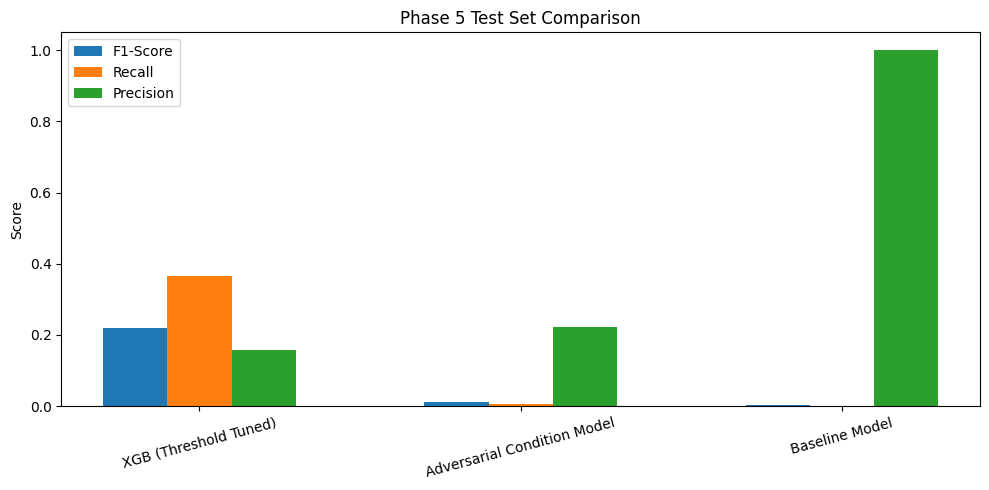

Plot saved as 'phase5_comparison.png'


In [45]:
# ============================================
# Part 8: Visualize Final Test Performance
# ============================================

plt.figure(figsize=(10, 5))

x = np.arange(len(results_df))
width = 0.2

plt.bar(x - width, results_df["F1-Score"], width, label="F1-Score")
plt.bar(x, results_df["Recall"], width, label="Recall")
plt.bar(x + width, results_df["Precision"], width, label="Precision")

plt.xticks(x, results_df["Model"], rotation=15)
plt.ylabel("Score")
plt.title("Phase 5 Test Set Comparison")
plt.legend()
plt.tight_layout()
plt.savefig("phase5_comparison.png", dpi=150)
plt.show()

print("Plot saved as 'phase5_comparison.png'")

## Step 9 - Honest limitations analysis
##### This section summarizes the limitations of the current model setup, especially the remaining weakness in minority-class detection.

In [46]:
# ============================================
# Part 9: Honest Limitations Analysis
# ============================================

print("="*80)
print("HONEST LIMITATIONS ANALYSIS")
print("="*80)

print("""
1. The model still struggles with minority-class detection under more difficult or adversarial conditions.

2. Threshold tuning improved the F1-score, but this may come at the cost of lower precision.

3. Feature selection helps reduce model complexity and training time, but some useful predictive information may be lost.

4. Ensemble models did not outperform the best tuned single model in the previous phase.

5. Further improvement may require stronger adversarial augmentation, feature engineering, or probability calibration.

6. Since the test set is held out for final evaluation, no further tuning should be done based on these test results.
""")

HONEST LIMITATIONS ANALYSIS

1. The model still struggles with minority-class detection under more difficult or adversarial conditions.

2. Threshold tuning improved the F1-score, but this may come at the cost of lower precision.

3. Feature selection helps reduce model complexity and training time, but some useful predictive information may be lost.

4. Ensemble models did not outperform the best tuned single model in the previous phase.

5. Further improvement may require stronger adversarial augmentation, feature engineering, or probability calibration.

6. Since the test set is held out for final evaluation, no further tuning should be done based on these test results.



In [47]:
# ============================================
# Part 12: Final Recommendation
# ============================================

print("="*80)
print("FINAL RECOMMENDATION")
print("="*80)

best_model_name = results_df.iloc[0]["Model"]
best_model_f1 = results_df.iloc[0]["F1-Score"]

print(f"Best model on held-out test set: {best_model_name}")
print(f"Final F1-score: {best_model_f1:.4f}")

print("\nRecommendation:")
print("Use the best-performing model from the held-out test evaluation as the final deployment candidate.")

FINAL RECOMMENDATION
Best model on held-out test set: XGB (Threshold Tuned)
Final F1-score: 0.2207

Recommendation:
Use the best-performing model from the held-out test evaluation as the final deployment candidate.
